In [1]:
# 3D Particle Visualization with Rerun
# Run experiment for "goat" video and visualize particles in 3D

import os
import sys
import numpy as np
import jax
import jax.numpy as jnp
from jax.random import key as jkey

# JAX compilation cache setup
cache_dir = os.path.join(os.getcwd(), ".jax_cache")
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
jax.config.update("jax_compilation_cache_dir", cache_dir)
jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
jax.experimental.compilation_cache.compilation_cache.set_cache_dir(cache_dir)

# Add workspace root to path to import from main script
workspace_root = os.path.dirname(os.getcwd())  # Go up from plotting_scripts to workspace root
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

# Import rerun
import rerun as rr

# Import functions from the main tracking script
from dino_tracking_subsampling_dense_eval import (
    process_video,
    NUM_BLOBS,
    NUM_HYPERBLOBS_ORIGINAL,
    FOCAL_LENGTH,
    BLOB_COUNTING_THRESHOLD,
    RANDOM_SEED,
    DAVIS_3D_MOTION_PATH,
    DAVIS_SEGMASKS_PATH,
    DAVIS_RGB_PATH,
    DINO_PATH_TEMPLATE,
    EXPERIMENT_SAVE_DIR
)

print("Setup complete!")


Setup complete!


In [2]:
# Override paths with correct locations for this system
import dino_tracking_subsampling_dense_eval as tracking_module

# Update paths to use correct directories
tracking_module.DAVIS_3D_MOTION_PATH = "/home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_npzs"
tracking_module.DINO_PATH_TEMPLATE = '/home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_dino/{}_dino_pca_per_pixel.npz'

# Set segmentation masks path (structure: path/goat/00000.png)
import os
segmask_path = "/home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_segmasks"
if os.path.exists(segmask_path):
    tracking_module.DAVIS_SEGMASKS_PATH = segmask_path
    print(f"Using segmentation masks at: {segmask_path}")
else:
    print(f"Warning: Segmentation mask path not found: {segmask_path}")
    print("Trying default from module.")

tracking_module.USE_SAM_FRAME0 = False
print("Disabled SAM frame0 (using regular segmentation masks)")

# Update RGB path if it exists
tracking_module.DAVIS_RGB_PATH = "/home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_rgb_frames"

print("\nUpdated paths:")
print(f"  3D Motion: {tracking_module.DAVIS_3D_MOTION_PATH}")
print(f"  DINO Features: {tracking_module.DINO_PATH_TEMPLATE}")
print(f"  Segmentation Masks: {tracking_module.DAVIS_SEGMASKS_PATH}")
print(f"  RGB Frames: {tracking_module.DAVIS_RGB_PATH}")

# Run experiment for "goat" video only
VIDEO_NAME = "camel"
SUBSAMPLING_PERCENTAGE = 100.0  # Use full resolution

print(f"\nRunning experiment for video: {VIDEO_NAME}")
print(f"Subsampling: {SUBSAMPLING_PERCENTAGE}%")

# Process the video
result = process_video(
    video_name=VIDEO_NAME,
    subsampling_percentage=SUBSAMPLING_PERCENTAGE,
    subsampled_indices=None,
    run_save_dir=None
)

if result is None:
    raise RuntimeError(f"Failed to process video {VIDEO_NAME}")

print(f"\nExperiment complete!")
print(f"Number of frames: {len(result['tracking_data'])}")
print(f"Image dimensions: {result['img_dims']}")


Using segmentation masks at: /home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_segmasks
Disabled SAM frame0 (using regular segmentation masks)

Updated paths:
  3D Motion: /home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_npzs
  DINO Features: /home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_dino/{}_dino_pca_per_pixel.npz
  Segmentation Masks: /home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_segmasks
  RGB Frames: /home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_rgb_frames

Running experiment for video: camel
Subsampling: 100.0%

Processing: camel | Subsampling: 100.0%
Running initial Gibbs sweeps...
Running tracking...
JIT compiling tracking function...
Measuring FPS after JIT compilation...
Tracking FPS: 1.86 frames/second (total time: 47.35s for 88 frames)


Dense Evaluating Blob Assignments: 100%|██████████| 89/89 [00:17<00:00,  5.03it/s]


Computing error rates...
is_mask_subsampled? ~~~~~~~~~~~> : False

📊 Processing dataset: camel

📈 Trial Results for camel:
Trial    Recall (%)   Precision  FPR      Jaccard  Accuracy   MW-F1-A    MW-F1-F    MW-J-A   MW-J-F   MW-Acc-A   MW-Acc-F   AUC     
--------------------------------------------------------------------------------------------------------------------------------------
1        80.29        0.999      0.000    0.802    0.964      0.892      0.956      0.813    0.917    0.963      0.979      0.001   
--------------------------------------------------------------------------------------------------------------------------------------
Note: MW-F1-A = Matter-Weighted F1 (Adaptive weights), MW-F1-F = Matter-Weighted F1 (Fixed frame-0 weights)
      MW-J-A = Matter-Weighted Jaccard (Adaptive weights), MW-J-F = Matter-Weighted Jaccard (Fixed frame-0 weights)
      MW-Acc-A = Matter-Weighted Accuracy (Adaptive weights), MW-Acc-F = Matter-Weighted Accuracy (Fixed frame-0 weig

In [3]:
# Extract particle data from tracking results
tracking_data = result['tracking_data']
segmentation_masks = result['segmentation_masks']
img_dims = result['img_dims']

# Extract particle means and covariances for each frame
particle_means = []  # List of (T, N, 3) arrays
particle_covs = []   # List of (T, N, 3, 3) arrays
particle_weights = []  # List of (T, N) arrays
is_object_particle = []  # List of (T, N) boolean arrays

fx = fy = FOCAL_LENGTH
cx = img_dims[1] / 2.0
cy = img_dims[0] / 2.0

# Determine object particles from frame 0 (same logic as compute_error_rates)
frame0 = tracking_data[0]
blob_assignments_frame0 = frame0['blob_assignments']
n_blobs_frame0 = frame0['n_blobs']
gt_mask_frame0 = segmentation_masks[0]

# Count pixels per blob in frame 0
blob_pixel_counts_frame0 = np.bincount(
    blob_assignments_frame0[blob_assignments_frame0 < n_blobs_frame0],
    minlength=n_blobs_frame0
)
significant_blobs = np.where(blob_pixel_counts_frame0 >= BLOB_COUNTING_THRESHOLD)[0]

# Project blob means to 2D and determine object vs background particles
blob_means_frame0 = frame0['blob_means']
x_2d = (blob_means_frame0[:, 0] / (blob_means_frame0[:, 2] + 1e-8)) * fx + cx
y_2d = (blob_means_frame0[:, 1] / (blob_means_frame0[:, 2] + 1e-8)) * fy + cy
x_2d = np.clip(x_2d.astype(int), 0, img_dims[1] - 1)
y_2d = np.clip(y_2d.astype(int), 0, img_dims[0] - 1)

object_blobs_frame0 = []
background_blobs_frame0 = []

for blob_idx in significant_blobs:
    pixel_idx = y_2d[blob_idx] * img_dims[1] + x_2d[blob_idx]
    is_on_mask = pixel_idx < len(gt_mask_frame0) and gt_mask_frame0[pixel_idx]
    if is_on_mask:
        object_blobs_frame0.append(blob_idx)
    else:
        background_blobs_frame0.append(blob_idx)

object_blobs_frame0 = np.array(object_blobs_frame0)
background_blobs_frame0 = np.array(background_blobs_frame0)

print(f"Found {len(object_blobs_frame0)} object particles and {len(background_blobs_frame0)} background particles")

# Extract data for all frames
for frame_idx in range(len(tracking_data)):
    frame = tracking_data[frame_idx]
    blob_means = np.array(frame['blob_means'])  # (N, 3)
    blob_covs = np.array(frame['blob_covs'])    # (N, 3, 3)
    blob_weights = np.array(frame['blob_weights'])  # (N,)
    n_blobs = frame['n_blobs']
    
    # Determine which particles are object particles (based on frame 0 classification)
    # Only consider particles that still exist in current frame
    is_object = np.zeros(n_blobs, dtype=bool)
    for obj_idx in object_blobs_frame0:
        if obj_idx < n_blobs:
            is_object[obj_idx] = True
    
    particle_means.append(blob_means)
    particle_covs.append(blob_covs)
    particle_weights.append(blob_weights)
    is_object_particle.append(is_object)

print(f"Extracted data for {len(particle_means)} frames")
print(f"Particle means shape: {particle_means[0].shape}")
print(f"Particle covs shape: {particle_covs[0].shape}")


Found 76 object particles and 424 background particles
Extracted data for 89 frames
Particle means shape: (500, 3)
Particle covs shape: (500, 3, 3)


In [4]:
# ============================================================================
# COMMENTED OUT: Cell 4
# ============================================================================
if False:  # Comment out entire cell
    # ============================================================================
    # COMMENTED OUT: Complete 3D visualization: pixels + ellipsoids for first 10 frames
    # ============================================================================
    # This cell is commented out - uncomment to use
    if False:
        import cv2
        from glob import glob
        from scipy.linalg import eigh

    # Helper function to create ellipsoid mesh from covariance
    def create_ellipsoid_mesh(mean, cov, scale=1.0, num_points=32):
        """Create ellipsoid mesh vertices from mean and covariance matrix"""
        # Eigenvalue decomposition
        eigenvals, eigenvecs = eigh(cov)
        eigenvals = np.maximum(eigenvals, 1e-6)
        radii = np.sqrt(eigenvals) * scale
    
        # Create unit sphere
        u = np.linspace(0, 2 * np.pi, num_points)
        v = np.linspace(0, np.pi, num_points)
        u, v = np.meshgrid(u, v)
    
        # Unit sphere coordinates
        x = np.sin(v) * np.cos(u)
        y = np.sin(v) * np.sin(u)
        z = np.cos(v)
    
        # Reshape to (N, 3)
        sphere_points = np.stack([x.flatten(), y.flatten(), z.flatten()], axis=1)
    
        # Scale by radii
        sphere_points = sphere_points * radii
    
        # Rotate by eigenvector matrix
        sphere_points = sphere_points @ eigenvecs.T
    
        # Translate to mean
        ellipsoid_points = sphere_points + mean
    
        # Create triangular faces for mesh
        n_u, n_v = num_points, num_points
        faces = []
        for i in range(n_v - 1):
            for j in range(n_u - 1):
                idx = i * n_u + j
                faces.append([idx, idx + 1, idx + n_u])
                faces.append([idx + 1, idx + n_u + 1, idx + n_u])
    
        return ellipsoid_points, np.array(faces)

    # Limit to first 10 frames
    NUM_FRAMES_TO_VISUALIZE = 10
    num_frames = min(NUM_FRAMES_TO_VISUALIZE, len(tracking_data))

    # Control parameters for visualization
    MIN_PIXELS_FOR_ELLIPSOID = -1  # Minimum pixels required to show ellipsoid (-1 means show all)
    ELLIPSOID_SCALE = 2.0  # Scale factor for ellipsoid sizes
    SHOW_ONLY_OBJECT_PARTICLES = False  # If True, only show object particles; if False, show all particles

    # ===== COMPUTE PARTICLE COLORS FROM RGB FRAMES =====
    print("Loading RGB frames to compute particle colors...")
    rgb_base_path = "/home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_rgb_frames"
    rgb_dir = os.path.join(rgb_base_path, VIDEO_NAME)
    rgb_files = sorted(glob(os.path.join(rgb_dir, "*.jpg")))
    if len(rgb_files) == 0:
        rgb_files = sorted(glob(os.path.join(rgb_dir, "*.png")))

    rgb_frames = []
    if len(rgb_files) > 0:
        for rgb_file in rgb_files[:num_frames]:
            frame = cv2.imread(rgb_file)
            if frame is not None:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                rgb_frames.append(frame)
        print(f"Loaded {len(rgb_frames)} RGB frames")
    else:
        print(f"Warning: No RGB frames found in {rgb_dir}")

    # Compute average colors for each particle in each frame
    print("Computing average colors per particle...")
    particle_colors = []  # List of (N, 3) arrays with RGB colors

    for frame_idx in range(num_frames):
        frame_data = tracking_data[frame_idx]
        blob_assignments = frame_data['blob_assignments']
        n_blobs = frame_data['n_blobs']
    
        # Reshape assignments to image dimensions
        blob_assignments_2d = blob_assignments.reshape(img_dims)
    
        # Get RGB frame
        if frame_idx < len(rgb_frames):
            rgb_frame = rgb_frames[frame_idx]
            # Resize if needed
            if rgb_frame.shape[:2] != img_dims:
                rgb_frame = cv2.resize(rgb_frame, (img_dims[1], img_dims[0]), interpolation=cv2.INTER_LINEAR)
        else:
            # Use default gray color if no RGB frame
            rgb_frame = np.full((img_dims[0], img_dims[1], 3), 128, dtype=np.uint8)
    
        # Compute average color per blob
        blob_colors = np.zeros((n_blobs, 3), dtype=np.float32)
        for blob_idx in range(n_blobs):
            mask = (blob_assignments_2d == blob_idx)
            if np.any(mask):
                blob_colors[blob_idx] = np.mean(rgb_frame[mask], axis=0)
            else:
                blob_colors[blob_idx] = [128, 128, 128]  # Default gray
    
        particle_colors.append(blob_colors.astype(np.uint8))

    print(f"Computed colors for {len(particle_colors)} frames")

    # ===== INITIALIZE RERUN VISUALIZATION =====
    # Initialize rerun session
    rr.init("3d_complete_visualization", spawn=True)

    # Set up coordinate system
    rr.log("world", rr.ViewCoordinates.RIGHT_HAND_Y_UP)

    particle_type_str = "object particles only" if SHOW_ONLY_OBJECT_PARTICLES else "all particles (object and background)"
    print(f"\nVisualizing {num_frames} frames with:")
    print(f"  - All 3D pixels colored by assigned particle")
    print(f"  - Ellipsoids for {particle_type_str} with >{MIN_PIXELS_FOR_ELLIPSOID} pixels")
    print(f"  - Control: SHOW_ONLY_OBJECT_PARTICLES = {SHOW_ONLY_OBJECT_PARTICLES}")

    # Visualize each frame
    for frame_idx in range(num_frames):
        frame_data = tracking_data[frame_idx]
    
        # Get 3D positions and assignments
        datapoint_positions = frame_data['datapoint_positions']  # (H*W, 3) - 3D positions
        blob_assignments = frame_data['blob_assignments']  # (H*W,) - particle assignments
        n_blobs = frame_data['n_blobs']
    
        # Filter out outlier assignments (particles >= n_blobs are outliers)
        valid_mask = blob_assignments < n_blobs
        valid_positions = datapoint_positions[valid_mask]
        valid_assignments = blob_assignments[valid_mask]
    
        # Count pixels per blob
        blob_pixel_counts = np.bincount(valid_assignments, minlength=n_blobs)
    
        # Set timeline
        rr.set_time_sequence("frame", frame_idx)
    
        # ===== VISUALIZE ALL PIXELS (NO FILTERING) =====
        # Get colors for each pixel based on assigned particle
        # Use the average colors computed from RGB frames (particle_colors from cell 3)
        if frame_idx < len(particle_colors):
            # Get the average color for each particle from the computed particle_colors
            particle_colors_frame = particle_colors[frame_idx]  # (n_blobs, 3) - RGB colors
            # Map each pixel's assignment to its particle's average color
            pixel_colors = particle_colors_frame[valid_assignments]  # (N, 3)
        else:
            # Fallback: use gray if colors not computed for this frame
            pixel_colors = np.full((len(valid_assignments), 3), 128, dtype=np.uint8)
    
        # Convert to RGBA
        num_pixels = len(valid_positions)
        pixel_colors_rgba = np.zeros((num_pixels, 4), dtype=np.uint8)
        pixel_colors_rgba[:, :3] = pixel_colors
        pixel_colors_rgba[:, 3] = 255  # Full opacity
    
        # Log pixels as 3D points
        rr.log(
            "pixels/3d_points",
            rr.Points3D(
                positions=valid_positions,
                colors=pixel_colors_rgba,
                radii=0.01  # Larger point size for better visibility
            )
        )
    
        # ===== VISUALIZE ELLIPSOIDS FOR PARTICLES WITH >MIN_PIXELS PIXELS =====
        # Get particle means and covariances for this frame
        means = particle_means[frame_idx]  # (n_blobs, 3)
        covs = particle_covs[frame_idx]     # (n_blobs, 3, 3)
        colors = particle_colors[frame_idx] if frame_idx < len(particle_colors) else None
    
        # Get object particle mask for this frame
        is_object = is_object_particle[frame_idx]  # (n_blobs,) boolean array
    
        # Filter particles based on control parameter
        if SHOW_ONLY_OBJECT_PARTICLES:
            # Only show object particles with >MIN_PIXELS pixels
            ellipsoid_mask = (blob_pixel_counts > MIN_PIXELS_FOR_ELLIPSOID) & is_object
        else:
            # Show ALL particles (object and background) with >MIN_PIXELS pixels
            ellipsoid_mask = blob_pixel_counts > MIN_PIXELS_FOR_ELLIPSOID
        ellipsoid_indices = np.where(ellipsoid_mask)[0]
    
        for blob_idx in ellipsoid_indices:
            if blob_idx >= n_blobs:
                continue
            
            mean = means[blob_idx]
            cov = covs[blob_idx]
        
            # Get color for this particle
            if colors is not None:
                color_rgb = colors[blob_idx]  # RGB color as uint8 array
            else:
                color_rgb = np.array([128, 128, 128], dtype=np.uint8)  # Gray
        
            # Create ellipsoid mesh from covariance
            vertices, faces = create_ellipsoid_mesh(mean, cov, scale=ELLIPSOID_SCALE)
            num_vertices = len(vertices)
        
            # Convert RGB to RGBA for mesh vertices
            vertex_colors = np.zeros((num_vertices, 4), dtype=np.uint8)
            vertex_colors[:, :3] = color_rgb  # Set RGB channels
            vertex_colors[:, 3] = 255  # Full opacity
        
            # Log ellipsoid as mesh (Rerun doesn't have native Ellipsoid3D, so we use Mesh3D)
            rr.log(
                f"ellipsoids/particle_{blob_idx}",
                rr.Mesh3D(
                    vertex_positions=vertices,
                    triangle_indices=faces,
                    vertex_colors=vertex_colors
                )
            )

    print("\n" + "="*60)
    print("Complete visualization ready! Check the Rerun viewer.")
    print("="*60)
    print("\nTips:")
    print("  - All 3D pixels are shown, colored by their assigned particle's average color")
    print(f"  - Ellipsoids show {particle_type_str} with >{MIN_PIXELS_FOR_ELLIPSOID} assigned pixels")
    print(f"  - Control: SHOW_ONLY_OBJECT_PARTICLES = {SHOW_ONLY_OBJECT_PARTICLES}")
    print("  - Use timeline slider to scrub through the first 10 frames")
    print("  - Use mouse to rotate/pan/zoom the 3D view")


In [5]:
# ============================================================================
# COMMENTED OUT: Cell 5
# ============================================================================
if False:  # Comment out entire cell
    # ============================================================================
    # COMMENTED OUT: Dual Point Cloud Visualization: Original RGB vs Particle-Assigned Colors
    # ============================================================================
    # This cell is commented out - uncomment to use
    if False:
        import cv2
        from glob import glob

    # Control parameters
    NUM_FRAMES_TO_VISUALIZE = 10
    num_frames = min(NUM_FRAMES_TO_VISUALIZE, len(tracking_data))
    BACKGROUND_DARKENING_FACTOR = 1.0  # Make background particles darker (0.0 = black, 1.0 = no change)
    POINT_SUBSAMPLE_FACTOR = 10  # Show every Nth point (1 = all points, 10 = every 10th point)
    POINT_RADIUS = 0.02  # Size of points in the visualization (larger = more visible)

    # ===== LOAD RGB FRAMES FOR ORIGINAL COLORS =====
    print("Loading RGB frames to get original colors...")
    rgb_base_path = "/home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_rgb_frames"
    rgb_dir = os.path.join(rgb_base_path, VIDEO_NAME)
    rgb_files = sorted(glob(os.path.join(rgb_dir, "*.jpg")))
    if len(rgb_files) == 0:
        rgb_files = sorted(glob(os.path.join(rgb_dir, "*.png")))

    rgb_frames = []
    if len(rgb_files) > 0:
        for rgb_file in rgb_files[:num_frames]:
            frame = cv2.imread(rgb_file)
            if frame is not None:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                rgb_frames.append(frame)
        print(f"Loaded {len(rgb_frames)} RGB frames")
    else:
        print(f"Warning: No RGB frames found in {rgb_dir}")

    # ===== COMPUTE PARTICLE COLORS =====
    print("Computing average colors per particle...")
    particle_colors = []  # List of (N, 3) arrays with RGB colors

    for frame_idx in range(num_frames):
        frame_data = tracking_data[frame_idx]
        blob_assignments = frame_data['blob_assignments']
        n_blobs = frame_data['n_blobs']
    
        # Reshape assignments to image dimensions
        blob_assignments_2d = blob_assignments.reshape(img_dims)
    
        # Get RGB frame
        if frame_idx < len(rgb_frames):
            rgb_frame = rgb_frames[frame_idx]
            # Resize if needed
            if rgb_frame.shape[:2] != img_dims:
                rgb_frame = cv2.resize(rgb_frame, (img_dims[1], img_dims[0]), interpolation=cv2.INTER_LINEAR)
        else:
            # Use default gray color if no RGB frame
            rgb_frame = np.full((img_dims[0], img_dims[1], 3), 128, dtype=np.uint8)
    
        # Compute average color per blob
        blob_colors = np.zeros((n_blobs, 3), dtype=np.float32)
        for blob_idx in range(n_blobs):
            mask = (blob_assignments_2d == blob_idx)
            if np.any(mask):
                blob_colors[blob_idx] = np.mean(rgb_frame[mask], axis=0)
            else:
                blob_colors[blob_idx] = [128, 128, 128]  # Default gray
    
        particle_colors.append(blob_colors.astype(np.uint8))

    print(f"Computed colors for {len(particle_colors)} frames")

    # ===== INITIALIZE RERUN VISUALIZATION =====
    # Initialize separate rerun session
    rr.init("dual_point_cloud_visualization", spawn=True)

    # Set up coordinate system
    rr.log("world", rr.ViewCoordinates.RIGHT_HAND_Y_UP)

    print(f"\nVisualizing {num_frames} frames with two point clouds:")
    print(f"  - Original RGB colors (left)")
    print(f"  - Particle-assigned colors (right, background particles darkened by {BACKGROUND_DARKENING_FACTOR:.1%})")
    print(f"  - Point subsampling: every {POINT_SUBSAMPLE_FACTOR}th point")
    print(f"  - Point radius: {POINT_RADIUS}")

    # Visualize each frame
    for frame_idx in range(num_frames):
        frame_data = tracking_data[frame_idx]
    
        # Get 3D positions and assignments
        datapoint_positions = frame_data['datapoint_positions']  # (H*W, 3) - 3D positions
        blob_assignments = frame_data['blob_assignments']  # (H*W,) - particle assignments
        n_blobs = frame_data['n_blobs']
    
        # Filter out outlier assignments (particles >= n_blobs are outliers)
        valid_mask = blob_assignments < n_blobs
        valid_positions = datapoint_positions[valid_mask]
        valid_assignments = blob_assignments[valid_mask]
    
        # Subsample points for better performance and visibility
        if POINT_SUBSAMPLE_FACTOR > 1:
            subsample_indices = np.arange(0, len(valid_positions), POINT_SUBSAMPLE_FACTOR)
            valid_positions = valid_positions[subsample_indices]
            valid_assignments = valid_assignments[subsample_indices]
    
        # Get object particle mask for this frame (after subsampling)
        is_object = is_object_particle[frame_idx]  # (n_blobs,) boolean array
        is_object_pixel = is_object[valid_assignments]  # (N,) boolean array for each pixel (subsampled)
    
        # Set timeline
        rr.set_time_sequence("frame", frame_idx)
    
        # ===== POINT CLOUD 1: ORIGINAL RGB COLORS =====
        if frame_idx < len(rgb_frames):
            rgb_frame = rgb_frames[frame_idx]
            # Resize if needed
            if rgb_frame.shape[:2] != img_dims:
                rgb_frame = cv2.resize(rgb_frame, (img_dims[1], img_dims[0]), interpolation=cv2.INTER_LINEAR)
        
            # Get original RGB colors for valid pixels by projecting 3D positions back to 2D
            fx = fy = FOCAL_LENGTH
            cx = img_dims[1] / 2.0
            cy = img_dims[0] / 2.0
        
            # Project 3D positions to 2D pixel coordinates
            x_2d = (valid_positions[:, 0] / (valid_positions[:, 2] + 1e-8)) * fx + cx
            y_2d = (valid_positions[:, 1] / (valid_positions[:, 2] + 1e-8)) * fy + cy
            x_2d = np.clip(x_2d.astype(int), 0, img_dims[1] - 1)
            y_2d = np.clip(y_2d.astype(int), 0, img_dims[0] - 1)
        
            # Get RGB colors from the frame at these pixel positions
            original_colors = rgb_frame[y_2d, x_2d]  # (N, 3) RGB colors
        else:
            # Fallback: use gray if no RGB frame
            original_colors = np.full((len(valid_positions), 3), 128, dtype=np.uint8)
    
        # Convert to RGBA
        original_colors_rgba = np.zeros((len(valid_positions), 4), dtype=np.uint8)
        original_colors_rgba[:, :3] = original_colors
        original_colors_rgba[:, 3] = 255  # Full opacity
    
        # Log original RGB point cloud
        rr.log(
            "point_clouds/original_rgb",
            rr.Points3D(
                positions=valid_positions,
                colors=original_colors_rgba,
                radii=POINT_RADIUS
            )
        )
    
        # ===== POINT CLOUD 2: PARTICLE-ASSIGNED COLORS (with background darkened) =====
        if frame_idx < len(particle_colors):
            # Get the average color for each particle
            particle_colors_frame = particle_colors[frame_idx]  # (n_blobs, 3) - RGB colors
            # Map each pixel's assignment to its particle's average color
            particle_assigned_colors = particle_colors_frame[valid_assignments]  # (N, 3)
        else:
            # Fallback: use gray if colors not computed for this frame
            particle_assigned_colors = np.full((len(valid_positions), 3), 128, dtype=np.uint8)
    
        # Darken background particles
        particle_assigned_colors_darkened = particle_assigned_colors.copy().astype(np.float32)
        # Apply darkening to background particles
        background_mask = ~is_object_pixel
        particle_assigned_colors_darkened[background_mask] *= BACKGROUND_DARKENING_FACTOR
        particle_assigned_colors_darkened = np.clip(particle_assigned_colors_darkened, 0, 255).astype(np.uint8)
    
        # Convert to RGBA
        particle_colors_rgba = np.zeros((len(valid_positions), 4), dtype=np.uint8)
        particle_colors_rgba[:, :3] = particle_assigned_colors_darkened
        particle_colors_rgba[:, 3] = 255  # Full opacity
    
        # Log particle-assigned point cloud
        rr.log(
            "point_clouds/particle_assigned",
            rr.Points3D(
                positions=valid_positions,
                colors=particle_colors_rgba,
                radii=POINT_RADIUS
            )
        )

    print("\n" + "="*60)
    print("Dual point cloud visualization ready! Check the Rerun viewer.")
    print("="*60)
    print("\nTips:")
    print("  - Two point clouds are shown side by side")
    print("  - Left: Original RGB colors from the video frames")
    print("  - Right: Colors assigned by particle tracking (background particles are darker)")
    print(f"  - Background darkening factor: {BACKGROUND_DARKENING_FACTOR:.1%}")
    print(f"  - Point subsampling: showing every {POINT_SUBSAMPLE_FACTOR}th point")
    print(f"  - Point size: {POINT_RADIUS}")
    print("  - Use timeline slider to scrub through frames")
    print("  - Use mouse to rotate/pan/zoom the 3D view")


In [6]:
# Dual Point Cloud Visualization: Original RGB vs DINO Feature Projection
print("Creating dual point cloud visualization with DINO feature projections...")

# Import required libraries
import cv2
from glob import glob

# Control parameters
# Visualize only first and last frame
NUM_FRAMES_TO_VISUALIZE = len(tracking_data)  # Total frames available
frame_indices_to_visualize = [0, len(tracking_data) - 1] if len(tracking_data) > 1 else [0]
num_frames = len(frame_indices_to_visualize)
BACKGROUND_DARKENING_FACTOR = 1.0  # Make background particles darker (0.0 = black, 1.0 = no change)
POINT_SUBSAMPLE_FACTOR = 10  # Show every Nth point (1 = all points, 10 = every 10th point)
POINT_RADIUS = 0.05  # Size of points in the visualization (larger = more visible)
# No blending - showing separate clouds

# ===== LOAD DINO FEATURES =====
print("Loading DINO features...")
dino_path = tracking_module.DINO_PATH_TEMPLATE.format(VIDEO_NAME)
if not os.path.exists(dino_path):
    raise FileNotFoundError(f"DINO features not found: {dino_path}")

pca_data = np.load(dino_path)
pca_features_unnormalized = pca_data['pca_features_unnormalized']  # Shape: (T, H, W, num_features)
pca_data.close()

print(f"DINO features shape: {pca_features_unnormalized.shape}")

# Reshape DINO features to match tracking data dimensions
T, h, w, num_features = pca_features_unnormalized.shape
target_h, target_w = img_dims

if (h, w) != (target_h, target_w):
    # Resize DINO features to match image dimensions
    dino_features_resized = np.zeros((T, target_h, target_w, num_features), dtype=pca_features_unnormalized.dtype)
    for t in range(T):
        for c in range(num_features):
            dino_features_resized[t, :, :, c] = cv2.resize(
                pca_features_unnormalized[t, :, :, c],
                (target_w, target_h),
                interpolation=cv2.INTER_LINEAR
            )
    # Only use first and last frame
    dino_features = dino_features_resized[frame_indices_to_visualize].reshape(num_frames, -1, num_features)
else:
    # Only use first and last frame
    dino_features = pca_features_unnormalized[frame_indices_to_visualize].reshape(num_frames, -1, num_features)

print(f"Reshaped DINO features to: {dino_features.shape} (frames, pixels, features)")

# ===== LOAD RGB FRAMES FOR ORIGINAL COLORS (for left point cloud) =====
print("Loading RGB frames to get original colors...")
rgb_base_path = "/home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_rgb_frames"
rgb_dir = os.path.join(rgb_base_path, VIDEO_NAME)
rgb_files = sorted(glob(os.path.join(rgb_dir, "*.jpg")))
if len(rgb_files) == 0:
    rgb_files = sorted(glob(os.path.join(rgb_dir, "*.png")))

rgb_frames = []
if len(rgb_files) > 0:
    # Load only first and last frame
    for frame_idx in frame_indices_to_visualize:
        if frame_idx < len(rgb_files):
            frame = cv2.imread(rgb_files[frame_idx])
            if frame is not None:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                rgb_frames.append(frame)
    print(f"Loaded {len(rgb_frames)} RGB frames (first and last)")
else:
    print(f"Warning: No RGB frames found in {rgb_dir}")

# ===== COMPUTE AVERAGE RGB COLORS PER PARTICLE =====
print("Computing average RGB colors per particle...")
particle_rgb_colors = []  # List of (N, 3) arrays with RGB colors

for vis_idx, frame_idx in enumerate(frame_indices_to_visualize):
    frame_data = tracking_data[frame_idx]
    blob_assignments = frame_data['blob_assignments']
    n_blobs = frame_data['n_blobs']
    
    # Reshape assignments to image dimensions
    blob_assignments_2d = blob_assignments.reshape(img_dims)
    
    # Get RGB frame
    if vis_idx < len(rgb_frames):
        rgb_frame = rgb_frames[vis_idx]
        # Resize if needed
        if rgb_frame.shape[:2] != img_dims:
            rgb_frame = cv2.resize(rgb_frame, (img_dims[1], img_dims[0]), interpolation=cv2.INTER_LINEAR)
    else:
        # Use default gray color if no RGB frame
        rgb_frame = np.full((img_dims[0], img_dims[1], 3), 128, dtype=np.uint8)
    
    # Compute average color per blob
    blob_colors = np.zeros((n_blobs, 3), dtype=np.float32)
    for blob_idx in range(n_blobs):
        mask = (blob_assignments_2d == blob_idx)
        if np.any(mask):
            blob_colors[blob_idx] = np.mean(rgb_frame[mask], axis=0)
        else:
            blob_colors[blob_idx] = [128, 128, 128]  # Default gray
    
    particle_rgb_colors.append(blob_colors.astype(np.uint8))

print(f"Computed average RGB colors for {len(particle_rgb_colors)} frames")

# ===== COMPUTE AVERAGE DINO FEATURES PER PARTICLE =====
print("Computing average DINO features per particle...")
particle_dino_features = []  # List of (N, num_features) arrays

for vis_idx, frame_idx in enumerate(frame_indices_to_visualize):
    frame_data = tracking_data[frame_idx]
    blob_assignments = frame_data['blob_assignments']
    n_blobs = frame_data['n_blobs']
    
    # Reshape assignments to image dimensions
    blob_assignments_2d = blob_assignments.reshape(img_dims)
    
    # Get DINO features for this frame (shape: H*W, num_features)
    frame_dino_features = dino_features[vis_idx]  # (H*W, num_features)
    frame_dino_features_2d = frame_dino_features.reshape(img_dims[0], img_dims[1], num_features)
    
    # Compute average DINO feature per blob
    blob_dino_features = np.zeros((n_blobs, num_features), dtype=np.float32)
    for blob_idx in range(n_blobs):
        mask = (blob_assignments_2d == blob_idx)
        if np.any(mask):
            blob_dino_features[blob_idx] = np.mean(frame_dino_features_2d[mask], axis=0)
        else:
            blob_dino_features[blob_idx] = np.zeros(num_features, dtype=np.float32)
    
    particle_dino_features.append(blob_dino_features)

print(f"Computed DINO features for {len(particle_dino_features)} frames")

# ===== PROJECT DINO FEATURES TO RGB =====
print("Projecting DINO features to RGB space...")
# Use first 3 PCA components as RGB channels
# Normalize each component to [0, 255] range for visualization

particle_dino_rgb = []  # List of (N, 3) arrays with RGB colors from DINO features

for vis_idx in range(num_frames):
    blob_dino_features = particle_dino_features[vis_idx]  # (n_blobs, num_features)
    
    # Use first 3 components as RGB
    dino_rgb_components = blob_dino_features[:, :3]  # (n_blobs, 3)
    
    # Normalize each component independently to [0, 255]
    dino_rgb_normalized = np.zeros_like(dino_rgb_components)
    for c in range(3):
        component = dino_rgb_components[:, c]
        if component.max() > component.min():
            # Normalize to [0, 1] then scale to [0, 255]
            component_norm = (component - component.min()) / (component.max() - component.min())
            dino_rgb_normalized[:, c] = component_norm * 255
        else:
            dino_rgb_normalized[:, c] = 128  # Default gray if constant
    
    particle_dino_rgb.append(dino_rgb_normalized.astype(np.uint8))

print(f"Projected DINO features to RGB for {len(particle_dino_rgb)} frames")

# ===== COMPUTE AVERAGE MOTION VECTORS PER PARTICLE =====
print("Computing average motion vectors per particle...")
particle_motion_vectors = []  # List of (N, 3) arrays with 3D motion vectors

for vis_idx, frame_idx in enumerate(frame_indices_to_visualize):
    frame_data = tracking_data[frame_idx]
    blob_assignments = frame_data['blob_assignments']
    n_blobs = frame_data['n_blobs']
    
    # Get motion vectors (velocities) for this frame
    if 'datapoint_vels' in frame_data:
        datapoint_vels = frame_data['datapoint_vels']  # (H*W, 3) - 3D motion vectors
    else:
        # If motion vectors not available, use zeros
        print(f"Warning: datapoint_vels not found in frame {frame_idx}, using zeros")
        datapoint_vels = np.zeros((img_dims[0] * img_dims[1], 3), dtype=np.float32)
    
    # Reshape assignments to image dimensions
    blob_assignments_2d = blob_assignments.reshape(img_dims)
    datapoint_vels_2d = datapoint_vels.reshape(img_dims[0], img_dims[1], 3)
    
    # Compute average motion vector per blob
    blob_motion_vectors = np.zeros((n_blobs, 3), dtype=np.float32)
    for blob_idx in range(n_blobs):
        mask = (blob_assignments_2d == blob_idx)
        if np.any(mask):
            blob_motion_vectors[blob_idx] = np.mean(datapoint_vels_2d[mask], axis=0)
        else:
            blob_motion_vectors[blob_idx] = np.zeros(3, dtype=np.float32)
    
    particle_motion_vectors.append(blob_motion_vectors)

print(f"Computed average motion vectors for {len(particle_motion_vectors)} frames")

# ===== PROJECT MOTION VECTORS TO RGB =====
print("Projecting motion vectors to RGB space...")
# Normalize motion vectors (by magnitude) and use only x, y components (disregard z)
# Map normalized 2D motion vectors to RGB color space

particle_motion_rgb = []  # List of (N, 3) arrays with RGB colors from motion vectors

# Extract only x, y components and normalize by magnitude
particle_motion_xy = []  # List of (N, 2) arrays with normalized x, y motion

for vis_idx in range(num_frames):
    blob_motion = particle_motion_vectors[vis_idx]  # (n_blobs, 3)
    
    # Extract only x, y components (disregard z)
    blob_motion_xy = blob_motion[:, :2]  # (n_blobs, 2)
    
    # Normalize by magnitude (unit vectors)
    motion_magnitudes = np.linalg.norm(blob_motion_xy, axis=1, keepdims=True)
    motion_magnitudes = np.where(motion_magnitudes > 1e-6, motion_magnitudes, 1.0)  # Avoid division by zero
    blob_motion_xy_normalized = blob_motion_xy / motion_magnitudes
    
    particle_motion_xy.append(blob_motion_xy_normalized)

# Compute global normalization for color mapping (across all frames)
all_motion_xy = np.concatenate(particle_motion_xy, axis=0)  # (total_blobs, 2)
motion_min = all_motion_xy.min(axis=0)  # (2,)
motion_max = all_motion_xy.max(axis=0)  # (2,)
motion_range = motion_max - motion_min
motion_range = np.where(motion_range > 1e-6, motion_range, 1.0)  # Avoid division by zero

for vis_idx in range(num_frames):
    blob_motion_xy_norm = particle_motion_xy[vis_idx]  # (n_blobs, 2) - normalized unit vectors
    
    # Map normalized x, y to [0, 1] then scale to [0, 255]
    motion_normalized = (blob_motion_xy_norm - motion_min) / motion_range
    motion_normalized = np.clip(motion_normalized, 0, 1)
    
    # Convert to RGB: use x, y for R, G channels, set B to 128 (gray) or use magnitude
    # Option: use magnitude for blue channel
    blob_motion_original = particle_motion_vectors[vis_idx][:, :2]  # (n_blobs, 2)
    motion_magnitudes = np.linalg.norm(blob_motion_original, axis=1)  # (n_blobs,)
    # Normalize magnitude to [0, 1] for blue channel
    if motion_magnitudes.max() > 1e-6:
        magnitude_normalized = motion_magnitudes / motion_magnitudes.max()
    else:
        magnitude_normalized = np.zeros_like(motion_magnitudes)
    
    # Create RGB: R=x, G=y, B=magnitude
    motion_rgb = np.zeros((len(blob_motion_xy_norm), 3), dtype=np.uint8)
    motion_rgb[:, 0] = (motion_normalized[:, 0] * 255).astype(np.uint8)  # R = x
    motion_rgb[:, 1] = (motion_normalized[:, 1] * 255).astype(np.uint8)  # G = y
    motion_rgb[:, 2] = (magnitude_normalized * 255).astype(np.uint8)    # B = magnitude
    
    particle_motion_rgb.append(motion_rgb)

print(f"Projected motion vectors to RGB for {len(particle_motion_rgb)} frames")
print("  - Using normalized x, y components (z disregarded)")
print("  - R channel = normalized x, G channel = normalized y, B channel = magnitude")

# No blending - we'll show separate point clouds

# ===== INITIALIZE RERUN VISUALIZATION =====
# Initialize separate rerun session
rr.init("dual_point_cloud_dino_visualization", spawn=True)

# Set up coordinate system
rr.log("world", rr.ViewCoordinates.RIGHT_HAND_Y_UP)

# Note: Background color will be set after logging data using Blueprint API

print(f"\nVisualizing {num_frames} frames (first and last) with four point clouds:")
print(f"  - Frame indices: {frame_indices_to_visualize}")
print(f"  - Original RGB colors")
print(f"  - Average particle RGB colors (background particles darkened by {BACKGROUND_DARKENING_FACTOR:.1%})")
print(f"  - DINO feature colors (background particles darkened by {BACKGROUND_DARKENING_FACTOR:.1%})")
print(f"  - Motion Vector colors (background particles darkened by {BACKGROUND_DARKENING_FACTOR:.1%})")
print(f"  - Point subsampling: every {POINT_SUBSAMPLE_FACTOR}th point")
print(f"  - Point radius: {POINT_RADIUS}")

# Visualize each frame
for vis_idx, frame_idx in enumerate(frame_indices_to_visualize):
    frame_data = tracking_data[frame_idx]
    
    # Get 3D positions and assignments
    datapoint_positions = frame_data['datapoint_positions']  # (H*W, 3) - 3D positions
    blob_assignments = frame_data['blob_assignments']  # (H*W,) - particle assignments
    n_blobs = frame_data['n_blobs']
    
    # Filter out outlier assignments (particles >= n_blobs are outliers)
    valid_mask = blob_assignments < n_blobs
    valid_positions = datapoint_positions[valid_mask]
    valid_assignments = blob_assignments[valid_mask]
    
    # Subsample points for better performance and visibility
    if POINT_SUBSAMPLE_FACTOR > 1:
        subsample_indices = np.arange(0, len(valid_positions), POINT_SUBSAMPLE_FACTOR)
        valid_positions = valid_positions[subsample_indices]
        valid_assignments = valid_assignments[subsample_indices]
    
    # Flip x and y coordinates to fix orientation
    valid_positions_flipped = valid_positions.copy()
    valid_positions_flipped[:, 0] = -valid_positions_flipped[:, 0]  # Flip x coordinate
    valid_positions_flipped[:, 1] = -valid_positions_flipped[:, 1]  # Flip y coordinate
    
    # Get object particle mask for this frame (after subsampling)
    is_object = is_object_particle[frame_idx]  # (n_blobs,) boolean array
    is_object_pixel = is_object[valid_assignments]  # (N,) boolean array for each pixel (subsampled)
    
    # Set timeline
    rr.set_time_sequence("frame", vis_idx)
    
    # ===== POINT CLOUD 1: ORIGINAL RGB COLORS =====
    if vis_idx < len(rgb_frames):
        rgb_frame = rgb_frames[vis_idx]
        # Resize if needed
        if rgb_frame.shape[:2] != img_dims:
            rgb_frame = cv2.resize(rgb_frame, (img_dims[1], img_dims[0]), interpolation=cv2.INTER_LINEAR)
        
        # Get original RGB colors for valid pixels by projecting 3D positions back to 2D
        fx = fy = FOCAL_LENGTH
        cx = img_dims[1] / 2.0
        cy = img_dims[0] / 2.0
        
        # Project 3D positions to 2D pixel coordinates
        x_2d = (valid_positions[:, 0] / (valid_positions[:, 2] + 1e-8)) * fx + cx
        y_2d = (valid_positions[:, 1] / (valid_positions[:, 2] + 1e-8)) * fy + cy
        x_2d = np.clip(x_2d.astype(int), 0, img_dims[1] - 1)
        y_2d = np.clip(y_2d.astype(int), 0, img_dims[0] - 1)
        
        # Get RGB colors from the frame at these pixel positions
        original_colors = rgb_frame[y_2d, x_2d]  # (N, 3) RGB colors
    else:
        # Fallback: use gray if no RGB frame
        original_colors = np.full((len(valid_positions), 3), 128, dtype=np.uint8)
    
    # Convert to RGBA
    original_colors_rgba = np.zeros((len(valid_positions), 4), dtype=np.uint8)
    original_colors_rgba[:, :3] = original_colors
    original_colors_rgba[:, 3] = 255  # Full opacity
    
    # Log original RGB point cloud (under world frame, with flipped x and y)
    rr.log(
        "world/point_clouds/original_rgb",
        rr.Points3D(
            positions=valid_positions_flipped,
            colors=original_colors_rgba,
            radii=POINT_RADIUS
        )
    )
    
    # ===== POINT CLOUD 2: AVERAGE PARTICLE RGB COLORS (with background darkened) =====
    if vis_idx < len(particle_rgb_colors):
        # Get the average RGB color for each particle
        particle_rgb_colors_frame = particle_rgb_colors[vis_idx]  # (n_blobs, 3) - RGB colors
        # Map each pixel's assignment to its particle's average RGB color
        particle_assigned_colors = particle_rgb_colors_frame[valid_assignments]  # (N, 3)
    else:
        # Fallback: use gray if colors not computed for this frame
        particle_assigned_colors = np.full((len(valid_positions), 3), 128, dtype=np.uint8)
    
    # Darken background particles
    particle_assigned_colors_darkened = particle_assigned_colors.copy().astype(np.float32)
    # Apply darkening to background particles
    background_mask = ~is_object_pixel
    particle_assigned_colors_darkened[background_mask] *= BACKGROUND_DARKENING_FACTOR
    particle_assigned_colors_darkened = np.clip(particle_assigned_colors_darkened, 0, 255).astype(np.uint8)
    
    # Convert to RGBA
    particle_rgb_colors_rgba = np.zeros((len(valid_positions), 4), dtype=np.uint8)
    particle_rgb_colors_rgba[:, :3] = particle_assigned_colors_darkened
    particle_rgb_colors_rgba[:, 3] = 255  # Full opacity
    
    # Log average particle RGB color point cloud (under world frame, with flipped x and y)
    rr.log(
        "world/point_clouds/particle_rgb_colors",
        rr.Points3D(
            positions=valid_positions_flipped,
            colors=particle_rgb_colors_rgba,
            radii=POINT_RADIUS
        )
    )
    
    # ===== POINT CLOUD 3: DINO FEATURE COLORS (with background darkened) =====
    if vis_idx < len(particle_dino_rgb):
        # Get the DINO-RGB color for each particle
        particle_dino_rgb_frame = particle_dino_rgb[vis_idx]  # (n_blobs, 3) - RGB colors from DINO
        # Map each pixel's assignment to its particle's DINO-RGB color
        dino_assigned_colors = particle_dino_rgb_frame[valid_assignments]  # (N, 3)
    else:
        # Fallback: use gray if colors not computed for this frame
        dino_assigned_colors = np.full((len(valid_positions), 3), 128, dtype=np.uint8)
    
    # Darken background particles
    dino_assigned_colors_darkened = dino_assigned_colors.copy().astype(np.float32)
    # Apply darkening to background particles
    background_mask = ~is_object_pixel
    dino_assigned_colors_darkened[background_mask] *= BACKGROUND_DARKENING_FACTOR
    dino_assigned_colors_darkened = np.clip(dino_assigned_colors_darkened, 0, 255).astype(np.uint8)
    
    # Convert to RGBA
    dino_colors_rgba = np.zeros((len(valid_positions), 4), dtype=np.uint8)
    dino_colors_rgba[:, :3] = dino_assigned_colors_darkened
    dino_colors_rgba[:, 3] = 255  # Full opacity
    
    # Log DINO feature point cloud (under world frame, with flipped x and y)
    rr.log(
        "world/point_clouds/dino_features",
        rr.Points3D(
            positions=valid_positions_flipped,
            colors=dino_colors_rgba,
            radii=POINT_RADIUS
        )
    )
    
    # ===== POINT CLOUD 4: MOTION VECTOR COLORS (with background darkened) =====
    if vis_idx < len(particle_motion_rgb):
        # Get the motion-RGB color for each particle
        particle_motion_rgb_frame = particle_motion_rgb[vis_idx]  # (n_blobs, 3) - RGB colors from motion
        # Map each pixel's assignment to its particle's motion-RGB color
        motion_assigned_colors = particle_motion_rgb_frame[valid_assignments]  # (N, 3)
    else:
        # Fallback: use gray if colors not computed for this frame
        motion_assigned_colors = np.full((len(valid_positions), 3), 128, dtype=np.uint8)
    
    # Darken background particles
    motion_assigned_colors_darkened = motion_assigned_colors.copy().astype(np.float32)
    # Apply darkening to background particles
    motion_assigned_colors_darkened[background_mask] *= BACKGROUND_DARKENING_FACTOR
    motion_assigned_colors_darkened = np.clip(motion_assigned_colors_darkened, 0, 255).astype(np.uint8)
    
    # Convert to RGBA
    motion_colors_rgba = np.zeros((len(valid_positions), 4), dtype=np.uint8)
    motion_colors_rgba[:, :3] = motion_assigned_colors_darkened
    motion_colors_rgba[:, 3] = 255  # Full opacity
    
    # Log motion vector point cloud (under world frame, with flipped x and y)
    rr.log(
        "world/point_clouds/motion_vectors",
        rr.Points3D(
            positions=valid_positions_flipped,
            colors=motion_colors_rgba,
            radii=POINT_RADIUS
        )
    )

# Set background color to white and turn off grid using Blueprint API (after data is logged)
# Point clouds are now logged under "world/point_clouds/..." so they're in the world frame
try:
    import rerun.blueprint as rrb
    # Create a blueprint that shows the world entity with white background and no grid
    blueprint = rrb.Blueprint(
        rrb.Spatial3DView(
            origin="/world",  # World frame where point clouds are logged
            name="3D View",
            background=[255, 255, 255],  # White background
            grid=None,  # Turn off grid
        ),
        collapse_panels=True,
    )
    rr.send_blueprint(blueprint)
    print("Set background color to white and turned off grid")
    print("Point clouds are logged under world frame and should be visible")
except Exception as e:
    print(f"Note: Could not set background color/grid automatically: {e}")
    print("You can manually set these in the Rerun viewer: View > Background > White, and turn off grid")

print("\n" + "="*60)
print("Point cloud visualization with DINO features ready! Check the Rerun viewer.")
print("="*60)
print("\nTips:")
print("  - Four separate point clouds are shown:")
print("    1. Original RGB colors from the video frames")
print("    2. Average particle RGB colors (average color of all pixels assigned to each particle)")
print("    3. DINO feature colors (per-particle average DINO features projected to RGB)")
print("    4. Motion Vector colors (normalized x, y motion with magnitude)")
print(f"  - Background particles are darkened by {BACKGROUND_DARKENING_FACTOR:.1%} in particle RGB, DINO, and Motion clouds")
print(f"  - Point subsampling: showing every {POINT_SUBSAMPLE_FACTOR}th point")
print(f"  - Point size: {POINT_RADIUS}")
print("  - Average particle RGB colors show the mean color of all pixels assigned to each particle")
print("  - DINO features are projected using first 3 PCA components as RGB channels")
print("  - Motion vectors are normalized by magnitude and use only x, y components (z disregarded)")
print("  - Motion RGB: R=normalized x, G=normalized y, B=magnitude")
print("  - Use timeline slider to scrub through frames")
print("  - Use mouse to rotate/pan/zoom the 3D view")
print("  - Toggle visibility of each point cloud in Rerun viewer to compare them")


Creating dual point cloud visualization with DINO feature projections...
Loading DINO features...
DINO features shape: (90, 520, 960, 10)
Reshaped DINO features to: (2, 499200, 10) (frames, pixels, features)
Loading RGB frames to get original colors...
Loaded 2 RGB frames (first and last)
Computing average RGB colors per particle...
Computed average RGB colors for 2 frames
Computing average DINO features per particle...
Computed DINO features for 2 frames
Projecting DINO features to RGB space...
Projected DINO features to RGB for 2 frames
Computing average motion vectors per particle...
Computed average motion vectors for 2 frames
Projecting motion vectors to RGB space...
Projected motion vectors to RGB for 2 frames
  - Using normalized x, y components (z disregarded)
  - R channel = normalized x, G channel = normalized y, B channel = magnitude

Visualizing 2 frames (first and last) with four point clouds:
  - Frame indices: [0, 88]
  - Original RGB colors
  - Average particle RGB colo

/var/tmp/ipykernel_559931/2178408590.py:308: DeprecationWarning: Use `set_time(sequence=…)` instead.
    See: https://www.rerun.io/docs/reference/migration/migration-0-23 for more details.
  rr.set_time_sequence("frame", vis_idx)


In [ ]:
# Visualize particles in 3D using Rerun as colored ellipsoids
# Particles are colored by average motion and features (computed in Cell 5)
import numpy as np
from scipy.linalg import eigh

# Initialize rerun
rr.init("3d_particle_visualization_motion_features", spawn=True)

# Helper function to create ellipsoid mesh from covariance
def create_ellipsoid_mesh(mean, cov, scale=1.0, num_points=32):
    """Create ellipsoid mesh vertices from mean and covariance matrix"""
    # Eigenvalue decomposition
    eigenvals, eigenvecs = eigh(cov)
    eigenvals = np.maximum(eigenvals, 1e-6)
    radii = np.sqrt(eigenvals) * scale

    # Create unit sphere
    u = np.linspace(0, 2 * np.pi, num_points)
    v = np.linspace(0, np.pi, num_points)
    u, v = np.meshgrid(u, v)

    # Unit sphere coordinates
    x = np.sin(v) * np.cos(u)
    y = np.sin(v) * np.sin(u)
    z = np.cos(v)

    # Reshape to (N, 3)
    sphere_points = np.stack([x.flatten(), y.flatten(), z.flatten()], axis=1)

    # Scale by radii
    sphere_points = sphere_points * radii

    # Rotate by eigenvector matrix
    sphere_points = sphere_points @ eigenvecs.T

    # Translate to mean
    ellipsoid_points = sphere_points + mean

    # Create triangular faces for mesh
    n_u, n_v = num_points, num_points
    faces = []
    for i in range(n_v - 1):
        for j in range(n_u - 1):
            idx = i * n_u + j
            faces.append([idx, idx + 1, idx + n_u])
            faces.append([idx + 1, idx + n_u + 1, idx + n_u])

    return ellipsoid_points, np.array(faces)

# Check if motion, feature, and RGB colors are available from Cell 5
if 'particle_motion_rgb' not in globals() or 'particle_dino_rgb' not in globals():
    raise RuntimeError("particle_motion_rgb and particle_dino_rgb must be computed first. Please run Cell 5.")
if 'particle_rgb_colors' not in globals():
    print("Warning: particle_rgb_colors not found. RGB-colored particles will not be shown.")
    particle_rgb_colors = []

print("Creating 3D visualization with Rerun...")
print(f"Using motion and feature colors computed from {len(particle_motion_rgb)} frames")

# Set up coordinate system ONCE before any data logging (consistent across all frames)
# Log coordinate system without time so it applies to all frames
rr.log("world", rr.ViewCoordinates.RIGHT_HAND_Y_UP, timeless=True)

# Set visualization parameters
ELLIPSOID_SCALE = 2.0  # Scale factor for ellipsoid sizes
MAX_PARTICLES_TO_SHOW = 500  # Limit number of particles for performance
# Visualize only first and last frame
frame_indices_to_visualize = [0, len(particle_means) - 1] if len(particle_means) > 1 else [0]
NUM_FRAMES_TO_VISUALIZE = len(frame_indices_to_visualize)

print(f"Visualizing {NUM_FRAMES_TO_VISUALIZE} frames (first and last)")
print(f"Frame indices: {frame_indices_to_visualize}")

# Set up blueprint with consistent camera view BEFORE logging any data
# This ensures the camera orientation stays the same when scrolling through frames
try:
    import rerun.blueprint as rrb
    blueprint = rrb.Blueprint(
        rrb.Spatial3DView(
            origin="/world",
            name="3D View",
            background=[255, 255, 255],  # White background
        ),
        collapse_panels=True,
    )
    rr.send_blueprint(blueprint)
    print("Set up consistent camera view with white background")
except Exception as e:
    print(f"Note: Could not set up camera view automatically: {e}")
    print("You can manually set background to white in the Rerun viewer: View > Background > White")

# Apply consistent coordinate transformation to all frames
# Use the same transformation as in Cell 5 (flip x and y to fix orientation)
APPLY_COORDINATE_FLIP = True  # Set to False to disable coordinate flipping

# Visualize each frame with two sets of ellipsoids: one colored by motion, one by features
for vis_idx, frame_idx in enumerate(frame_indices_to_visualize):
    # Create copies of the original data for filtering (don't modify originals)
    means = particle_means[frame_idx].copy()
    covs = particle_covs[frame_idx].copy()
    weights = particle_weights[frame_idx].copy()
    is_object = is_object_particle[frame_idx].copy()
    n_particles_original = len(means)  # Store original count
    n_particles = n_particles_original
    
    # Apply consistent coordinate transformation (flip x and y to match Cell 5)
    if APPLY_COORDINATE_FLIP:
        means[:, 0] = -means[:, 0]  # Flip x coordinate
        means[:, 1] = -means[:, 1]  # Flip y coordinate
        # Also need to transform covariance matrices to match the coordinate flip
        # Flip matrix: diag([-1, -1, 1])
        flip_matrix = np.array([[-1, 0, 0], [0, -1, 0], [0, 0, 1]], dtype=np.float64)
        for i in range(n_particles):
            # Transform covariance: cov' = R @ cov @ R^T where R is the flip matrix
            covs[i] = flip_matrix @ covs[i] @ flip_matrix.T
    
    # Get motion and feature colors for this frame (create copies)
    # Note: particle_motion_rgb and particle_dino_rgb are computed for all frames in Cell 5
    # but we only need the ones corresponding to frame_indices_to_visualize
    # Since Cell 5 now only computes for first and last, vis_idx should match
    if vis_idx < len(particle_motion_rgb):
        motion_colors = particle_motion_rgb[vis_idx].copy()  # (n_blobs, 3) RGB colors from motion
    else:
        motion_colors = np.full((n_particles, 3), 128, dtype=np.uint8)  # Default gray
    
    if vis_idx < len(particle_dino_rgb):
        feature_colors = particle_dino_rgb[vis_idx].copy()  # (n_blobs, 3) RGB colors from features
    else:
        feature_colors = np.full((n_particles, 3), 128, dtype=np.uint8)  # Default gray
    
    # Get RGB colors for this frame (create copies)
    if vis_idx < len(particle_rgb_colors):
        rgb_colors = particle_rgb_colors[vis_idx].copy()  # (n_blobs, 3) RGB colors from video frames
    else:
        rgb_colors = np.full((n_particles, 3), 128, dtype=np.uint8)  # Default gray
    
    # Limit particles if too many (work on copies)
    if n_particles > MAX_PARTICLES_TO_SHOW:
        # Sample particles based on weights
        indices = np.argsort(weights)[-MAX_PARTICLES_TO_SHOW:]
        means = means[indices].copy()
        covs = covs[indices].copy()
        weights = weights[indices].copy()
        motion_colors = motion_colors[indices].copy()
        feature_colors = feature_colors[indices].copy()
        rgb_colors = rgb_colors[indices].copy()
        is_object = is_object[indices].copy()
        n_particles = MAX_PARTICLES_TO_SHOW
        print(f"Frame {frame_idx} (vis_idx {vis_idx}): Limited to top {MAX_PARTICLES_TO_SHOW} particles by weight (out of {n_particles_original} total)")
    
    # Filter out particles where first principal axis is much larger than second principal axis
    # This filters out highly elongated particles (needle-like shapes)
    # Filter based on ratio: first_principal_axis / second_principal_axis
    valid_particle_mask = np.ones(n_particles, dtype=bool)
    PRINCIPAL_AXIS_RATIO_THRESHOLD = 4.0  # Set to 0 or negative to disable filtering
    # Threshold meaning: filter if first_axis >= threshold * second_axis
    # Example: threshold=2.0 means filter if first axis is 2x or more than second axis
    # Higher threshold = less aggressive filtering (filters fewer particles)
    
    # Only apply filtering if threshold is positive
    if PRINCIPAL_AXIS_RATIO_THRESHOLD > 0:
        for i in range(n_particles):
            cov = covs[i]
            # Compute eigenvalues (principal axes lengths, squared)
            eigenvals, eigenvecs = eigh(cov)
            # Ensure eigenvalues are positive (they should be for covariance matrices)
            eigenvals = np.maximum(eigenvals, 1e-10)
            # Sort eigenvalues in descending order
            eigenvals_sorted = np.sort(eigenvals)[::-1]
            # Get first (largest) and second principal axes (square root of eigenvalues)
            first_principal_axis = np.sqrt(eigenvals_sorted[0])
            second_principal_axis = np.sqrt(eigenvals_sorted[1])
            # Compute ratio: first / second
            # Large ratio means first axis is much longer than second (elongated particle)
            if second_principal_axis > 1e-6:  # Avoid division by zero
                axis_ratio = first_principal_axis / second_principal_axis
                # Filter if ratio >= threshold (particle is too elongated)
                # For example, if threshold=2.0, filter when first >= 2*second
                if axis_ratio >= PRINCIPAL_AXIS_RATIO_THRESHOLD:
                    valid_particle_mask[i] = False
    
    num_filtered = np.sum(~valid_particle_mask)
    if PRINCIPAL_AXIS_RATIO_THRESHOLD > 0:
        if num_filtered > 0:
            print(f"Frame {frame_idx} (vis_idx {vis_idx}): Filtered out {num_filtered} particles with first/second principal axis ratio >= {PRINCIPAL_AXIS_RATIO_THRESHOLD}")
    else:
        print(f"Frame {frame_idx} (vis_idx {vis_idx}): Principal axis ratio filtering disabled (threshold={PRINCIPAL_AXIS_RATIO_THRESHOLD})")
    
    # Apply filter to all arrays (working on copies, originals are preserved)
    means = means[valid_particle_mask]
    covs = covs[valid_particle_mask]
    weights = weights[valid_particle_mask]
    motion_colors = motion_colors[valid_particle_mask]
    feature_colors = feature_colors[valid_particle_mask]
    rgb_colors = rgb_colors[valid_particle_mask]
    is_object = is_object[valid_particle_mask]
    n_particles = len(means)
    
    # Set timeline
    rr.set_time_sequence("frame", vis_idx)
    
    # Compute volumes for all ellipsoids (volume is proportional to sqrt(det(cov)))
    volumes = np.array([np.sqrt(np.linalg.det(cov)) for cov in covs])
    # Normalize volumes to [0, 1] range
    if volumes.max() > volumes.min():
        normalized_volumes = (volumes - volumes.min()) / (volumes.max() - volumes.min())
    else:
        normalized_volumes = np.ones(n_particles)
    # Invert: smaller volume = higher opacity (more opaque), larger volume = lower opacity (more transparent)
    # Map to opacity range [0.0, 1.0] for Rerun: smallest ellipsoids get 1.0 (fully opaque), largest get 0.25 (semi-transparent)
    opacity_from_volume = 1.0 - normalized_volumes * 0.75  # 1.0 - 0.75*normalized_volume
    opacity_from_volume = np.clip(opacity_from_volume, 0.25, 1.0)  # Ensure range [0.25, 1.0]
    
    # Optionally combine with weight-based opacity, or use volume-based opacity directly
    USE_WEIGHT_FOR_OPACITY = False  # Set to True to combine weight and volume
    if USE_WEIGHT_FOR_OPACITY and len(weights) > 0 and weights.max() > 0:
        normalized_weights = weights / weights.max()
        weight_opacity = 0.5 + 0.5 * normalized_weights  # Range [0.5, 1.0]
        # Combine: use minimum of both (more conservative)
        opacity_values = np.minimum(opacity_from_volume, weight_opacity)
    else:
        opacity_values = opacity_from_volume
    
    # Visualize particles as ellipsoids colored by motion
    for i in range(n_particles):
        mean = means[i]
        cov = covs[i]
        color_rgb = motion_colors[i]  # RGB color from motion
        opacity = opacity_values[i]  # Opacity inversely proportional to volume (larger = more transparent)
        
        # Create ellipsoid mesh
        vertices, faces = create_ellipsoid_mesh(mean, cov, scale=ELLIPSOID_SCALE)
        num_vertices = len(vertices)
        
        # Convert RGB to RGBA with opacity in alpha channel
        # Opacity is inversely proportional to volume (larger ellipsoids = more transparent)
        alpha_uint8 = int(opacity * 255)
        vertex_colors = np.zeros((num_vertices, 4), dtype=np.uint8)
        vertex_colors[:, :3] = color_rgb  # Set RGB channels from motion
        vertex_colors[:, 3] = alpha_uint8  # Set alpha channel based on volume (Rerun uses this for opacity)
        
        # Log ellipsoid as mesh (colored by motion) with opacity in alpha channel
        rr.log(
            f"world/motion_particles/ellipsoid_{i}",
            rr.Mesh3D(
                vertex_positions=vertices,
                triangle_indices=faces,
                vertex_colors=vertex_colors
            )
        )
    
    # Visualize particles as ellipsoids colored by features
    for i in range(n_particles):
        mean = means[i]
        cov = covs[i]
        color_rgb = feature_colors[i]  # RGB color from features
        opacity = opacity_values[i]  # Opacity inversely proportional to volume (larger = more transparent)
        
        # Create ellipsoid mesh
        vertices, faces = create_ellipsoid_mesh(mean, cov, scale=ELLIPSOID_SCALE)
        num_vertices = len(vertices)
        
        # Convert RGB to RGBA with opacity in alpha channel
        # Opacity is inversely proportional to volume (larger ellipsoids = more transparent)
        alpha_uint8 = int(opacity * 255)
        vertex_colors = np.zeros((num_vertices, 4), dtype=np.uint8)
        vertex_colors[:, :3] = color_rgb  # Set RGB channels from features
        vertex_colors[:, 3] = alpha_uint8  # Set alpha channel based on volume (Rerun uses this for opacity)
        
        # Log ellipsoid as mesh (colored by features) with opacity in alpha channel
        rr.log(
            f"world/feature_particles/ellipsoid_{i}",
            rr.Mesh3D(
                vertex_positions=vertices,
                triangle_indices=faces,
                vertex_colors=vertex_colors
            )
        )
    
    # Visualize particles as ellipsoids colored by RGB
    for i in range(n_particles):
        mean = means[i]
        cov = covs[i]
        color_rgb = rgb_colors[i]  # RGB color from video frames
        opacity = opacity_values[i]  # Opacity inversely proportional to volume (larger = more transparent)
        
        # Create ellipsoid mesh
        vertices, faces = create_ellipsoid_mesh(mean, cov, scale=ELLIPSOID_SCALE)
        num_vertices = len(vertices)
        
        # Convert RGB to RGBA with opacity in alpha channel
        # Opacity is inversely proportional to volume (larger ellipsoids = more transparent)
        alpha_uint8 = int(opacity * 255)
        vertex_colors = np.zeros((num_vertices, 4), dtype=np.uint8)
        vertex_colors[:, :3] = color_rgb  # Set RGB channels from video frames
        vertex_colors[:, 3] = alpha_uint8  # Set alpha channel based on volume (Rerun uses this for opacity)
        
        # Log ellipsoid as mesh (colored by RGB) with opacity in alpha channel
        rr.log(
            f"world/rgb_particles/ellipsoid_{i}",
            rr.Mesh3D(
                vertex_positions=vertices,
                triangle_indices=faces,
                vertex_colors=vertex_colors
            )
        )

print("\n" + "="*60)
print("Visualization complete! Check the Rerun viewer.")
print("="*60)
print("\nTips:")
print("  - Three sets of ellipsoids are shown:")
print("    1. motion_particles: Particles colored by average motion vectors")
print("       (R=normalized x, G=normalized y, B=magnitude)")
print("    2. feature_particles: Particles colored by average DINO features")
print("       (First 3 PCA components projected to RGB)")
print("    3. rgb_particles: Particles colored by average RGB colors from video frames")
print("  - Highly elongated particles (where first principal axis >> second principal axis) have been filtered out for clarity")
print("  - Ellipsoid opacity is inversely proportional to volume (larger ellipsoids = more transparent)")
print("  - Use mouse to rotate/pan/zoom the 3D view")
print("  - Use timeline slider to scrub through frames")
print("  - Ellipsoid size and shape represent particle covariance")
print("  - Toggle visibility of each particle set in Rerun viewer to compare them")


Creating 3D visualization with Rerun...
Using motion and feature colors computed from 2 frames
Visualizing 2 frames (first and last)
Frame indices: [0, 88]
Set up consistent camera view with white background
Frame 0 (vis_idx 0): Filtered out 150 particles with first/second principal axis ratio >= 4.0


/var/tmp/ipykernel_559931/3087990789.py:62: RerunWarning: log: TypeError(log() got an unexpected keyword argument 'timeless')
  rr.log("world", rr.ViewCoordinates.RIGHT_HAND_Y_UP, timeless=True)
/var/tmp/ipykernel_559931/3087990789.py:200: DeprecationWarning: Use `set_time(sequence=…)` instead.
    See: https://www.rerun.io/docs/reference/migration/migration-0-23 for more details.
  rr.set_time_sequence("frame", vis_idx)


Frame 88 (vis_idx 1): Filtered out 150 particles with first/second principal axis ratio >= 4.0

Visualization complete! Check the Rerun viewer.

Tips:
  - Two sets of ellipsoids are shown:
    1. motion_particles: Particles colored by average motion vectors
       (R=normalized x, G=normalized y, B=magnitude)
    2. feature_particles: Particles colored by average DINO features
       (First 3 PCA components projected to RGB)
  - Highly elongated particles (where first principal axis >> second principal axis) have been filtered out for clarity
  - Use mouse to rotate/pan/zoom the 3D view
  - Use timeline slider to scrub through frames
  - Ellipsoid size and shape represent particle covariance
  - Ellipsoid opacity represents particle weight
  - Toggle visibility of each particle set in Rerun viewer to compare them


In [16]:
# ============================================================================
# COMMENTED OUT: Cell 13
# ============================================================================
if False:  # Comment out entire cell
    # # Plot histogram of particle weights
    # %matplotlib inline
    # import matplotlib.pyplot as plt

    # print("Creating histogram of particle weights...")

    # # Collect all particle weights across all frames
    # all_weights = []
    # for frame_idx in range(len(particle_weights)):
    #     weights = particle_weights[frame_idx]
    #     all_weights.extend(weights.flatten())

    # all_weights = np.array(all_weights)

    # # Also get weights from frame 0 for comparison
    # frame0_weights = particle_weights[1]

    # # Create figure with subplots
    # fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # # Plot 1: Histogram of all weights across all frames
    # axes[0].hist(all_weights, bins=50, edgecolor='black', alpha=0.7)
    # axes[0].set_xlabel('Particle Weight', fontsize=12)
    # axes[0].set_ylabel('Frequency', fontsize=12)
    # axes[0].set_title('Distribution of Particle Weights (All Frames)', fontsize=14, fontweight='bold')
    # axes[0].grid(True, alpha=0.3)
    # axes[0].axvline(np.mean(all_weights), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_weights):.6f}')
    # axes[0].axvline(np.median(all_weights), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(all_weights):.6f}')
    # axes[0].legend()

    # # Plot 2: Histogram of frame 0 weights
    # axes[1].hist(frame0_weights, bins=50, edgecolor='black', alpha=0.7, color='orange')
    # axes[1].set_xlabel('Particle Weight', fontsize=12)
    # axes[1].set_ylabel('Frequency', fontsize=12)
    # axes[1].set_title('Distribution of Particle Weights (Frame 0)', fontsize=14, fontweight='bold')
    # axes[1].grid(True, alpha=0.3)
    # axes[1].axvline(np.mean(frame0_weights), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(frame0_weights):.6f}')
    # axes[1].axvline(np.median(frame0_weights), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(frame0_weights):.6f}')
    # axes[1].legend()

    # plt.tight_layout()
    # plt.show()

    # # Print statistics
    # print("\n" + "="*60)
    # print("PARTICLE WEIGHT STATISTICS")
    # print("="*60)
    # print(f"All frames:")
    # print(f"  Total weights: {len(all_weights)}")
    # print(f"  Mean: {np.mean(all_weights):.6f}")
    # print(f"  Median: {np.median(all_weights):.6f}")
    # print(f"  Std: {np.std(all_weights):.6f}")
    # print(f"  Min: {np.min(all_weights):.6f}")
    # print(f"  Max: {np.max(all_weights):.6f}")
    # print(f"\nFrame 0:")
    # print(f"  Total particles: {len(frame0_weights)}")
    # print(f"  Mean: {np.mean(frame0_weights):.6f}")
    # print(f"  Median: {np.median(frame0_weights):.6f}")
    # print(f"  Std: {np.std(frame0_weights):.6f}")
    # print(f"  Min: {np.min(frame0_weights):.6f}")
    # print(f"  Max: {np.max(frame0_weights):.6f}")
    # print("="*60)


SyntaxError: incomplete input (2649077892.py, line 66)

Creating 2D projection plots (X-Y plane) of 3D points and particles...


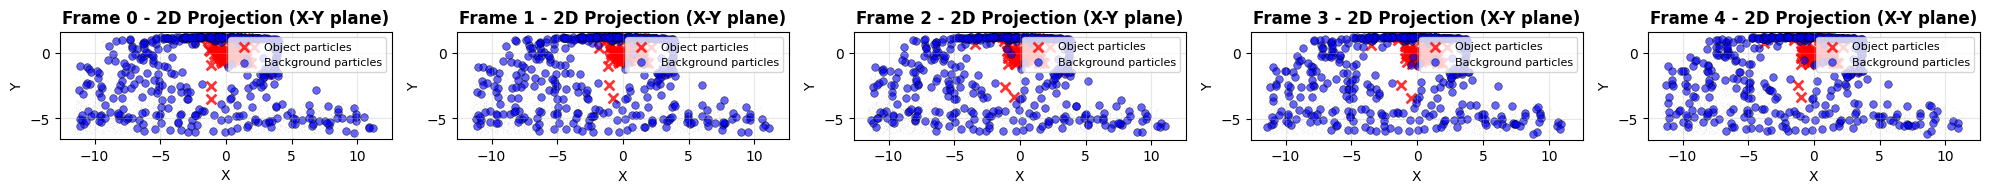


Plotted 5 frames showing 2D projection (X-Y plane)
  - Pixels shown as colored points (downsampled for performance)
  - Object particles shown as red X markers
  - Background particles shown as blue circles
  - Z axis (depth) is collapsed - only X and Y coordinates shown


In [ ]:
# ============================================================================
# COMMENTED OUT: Cell 14
# ============================================================================
if False:  # Comment out entire cell
    # # Plot 2D projection (X-Y plane) of 3D points and particles for first 5 frames
    # %matplotlib inline
    # import matplotlib.pyplot as plt

    # print("Creating 2D projection plots (X-Y plane) of 3D points and particles...")

    # # Limit to first 5 frames
    # NUM_FRAMES_TO_PLOT = 5
    # num_frames = min(NUM_FRAMES_TO_PLOT, len(tracking_data))

    # # Create figure with subplots
    # fig, axes = plt.subplots(1, num_frames, figsize=(20, 4))
    # if num_frames == 1:
    #     axes = [axes]  # Make it iterable

    # for plot_idx, frame_idx in enumerate(range(num_frames)):
    #     ax = axes[plot_idx]
    
    #     frame_data = tracking_data[frame_idx]
    
    #     # Get 3D positions and assignments
    #     datapoint_positions = frame_data['datapoint_positions']  # (H*W, 3) - 3D positions
    #     blob_assignments = frame_data['blob_assignments']  # (H*W,) - particle assignments
    #     n_blobs = frame_data['n_blobs']
    
    #     # Filter out outlier assignments
    #     valid_mask = blob_assignments < n_blobs
    #     valid_positions = datapoint_positions[valid_mask]
    #     valid_assignments = blob_assignments[valid_mask]
    
    #     # Project to 2D by taking X and Y coordinates (collapse Z axis)
    #     positions_2d = valid_positions[:, :2]  # (N, 2) - just X and Y
    
    #     # Get colors for pixels
    #     if frame_idx < len(particle_colors):
    #         particle_colors_frame = particle_colors[frame_idx]  # (n_blobs, 3) - RGB colors
    #         pixel_colors = particle_colors_frame[valid_assignments]  # (N, 3)
    #         # Normalize to [0, 1] for matplotlib
    #         pixel_colors_normalized = pixel_colors.astype(np.float32) / 255.0
    #     else:
    #         pixel_colors_normalized = np.full((len(valid_assignments), 3), 0.5, dtype=np.float32)
    
    #     # Downsample pixels for performance in matplotlib
    #     DOWNSAMPLE_FACTOR = max(1, len(positions_2d) // 10000)  # Show up to 10k points per frame
    #     if DOWNSAMPLE_FACTOR > 1:
    #         positions_2d = positions_2d[::DOWNSAMPLE_FACTOR]
    #         pixel_colors_normalized = pixel_colors_normalized[::DOWNSAMPLE_FACTOR]
    
    #     # Plot pixels as scatter points
    #     ax.scatter(
    #         positions_2d[:, 0],
    #         positions_2d[:, 1],
    #         c=pixel_colors_normalized,
    #         s=0.1,
    #         alpha=0.5,
    #         edgecolors='none'
    #     )
    
    #     # Plot particle means (projected to 2D)
    #     means = particle_means[frame_idx]  # (n_blobs, 3)
    #     means_2d = means[:, :2]  # (n_blobs, 2) - just X and Y
    
    #     # Get object particles for this frame
    #     is_object = is_object_particle[frame_idx]
    
    #     # Plot object particles in one color, background in another
    #     object_means_2d = means_2d[is_object]
    #     background_means_2d = means_2d[~is_object]
    
    #     if len(object_means_2d) > 0:
    #         ax.scatter(
    #             object_means_2d[:, 0],
    #             object_means_2d[:, 1],
    #             c='red',
    #             s=50,
    #             marker='x',
    #             linewidths=2,
    #             label='Object particles',
    #             alpha=0.8
    #         )
    
    #     if len(background_means_2d) > 0:
    #         ax.scatter(
    #             background_means_2d[:, 0],
    #             background_means_2d[:, 1],
    #             c='blue',
    #             s=30,
    #             marker='o',
    #             edgecolors='black',
    #             linewidths=0.5,
    #             label='Background particles',
    #             alpha=0.6
    #         )
    
    #     ax.set_xlabel('X', fontsize=10)
    #     ax.set_ylabel('Y', fontsize=10)
    #     ax.set_title(f'Frame {frame_idx} - 2D Projection (X-Y plane)', fontsize=12, fontweight='bold')
    #     ax.grid(True, alpha=0.3)
    #     ax.legend(fontsize=8, loc='upper right')
    #     ax.set_aspect('equal', adjustable='box')

    # plt.tight_layout()
    # plt.show()

    # print(f"\nPlotted {num_frames} frames showing 2D projection (X-Y plane)")
    # print("  - Pixels shown as colored points (downsampled for performance)")
    # print("  - Object particles shown as red X markers")
    # print("  - Background particles shown as blue circles")
    # print("  - Z axis (depth) is collapsed - only X and Y coordinates shown")


In [ ]:
# ============================================================================
# COMMENTED OUT: Cell 20
# ============================================================================
if False:  # Comment out entire cell
    # # Visualize particles in 3D using Rerun as colored ellipsoids
    # import numpy as np
    # from scipy.linalg import eigh
    # import cv2
    # from glob import glob

    # # Initialize rerun
    # rr.init("3d_particle_visualization", spawn=True)

    # # Helper function to create ellipsoid mesh from covariance
    # def create_ellipsoid_mesh(mean, cov, scale=1.0, num_points=32):
    #     """Create ellipsoid mesh vertices from mean and covariance matrix"""
    #     # Eigenvalue decomposition
    #     eigenvals, eigenvecs = eigh(cov)
    #     eigenvals = np.maximum(eigenvals, 1e-6)
    #     radii = np.sqrt(eigenvals) * scale
    
    #     # Create unit sphere
    #     u = np.linspace(0, 2 * np.pi, num_points)
    #     v = np.linspace(0, np.pi, num_points)
    #     u, v = np.meshgrid(u, v)
    
    #     # Unit sphere coordinates
    #     x = np.sin(v) * np.cos(u)
    #     y = np.sin(v) * np.sin(u)
    #     z = np.cos(v)
    
    #     # Reshape to (N, 3)
    #     sphere_points = np.stack([x.flatten(), y.flatten(), z.flatten()], axis=1)
    
    #     # Scale by radii
    #     sphere_points = sphere_points * radii
    
    #     # Rotate by eigenvector matrix
    #     sphere_points = sphere_points @ eigenvecs.T
    
    #     # Translate to mean
    #     ellipsoid_points = sphere_points + mean
    
    #     # Create triangular faces for mesh
    #     n_u, n_v = num_points, num_points
    #     faces = []
    #     for i in range(n_v - 1):
    #         for j in range(n_u - 1):
    #             idx = i * n_u + j
    #             faces.append([idx, idx + 1, idx + n_u])
    #             faces.append([idx + 1, idx + n_u + 1, idx + n_u])
    
    #     return ellipsoid_points, np.array(faces)

    # # Load RGB frames to compute average colors
    # print("Loading RGB frames to compute particle colors...")
    # # Use the correct RGB path
    # rgb_base_path = "/home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_rgb_frames"
    # rgb_dir = os.path.join(rgb_base_path, VIDEO_NAME)
    # print(f"Looking for RGB frames in: {rgb_dir}")
    # rgb_files = sorted(glob(os.path.join(rgb_dir, "*.jpg")))
    # if len(rgb_files) == 0:
    #     rgb_files = sorted(glob(os.path.join(rgb_dir, "*.png")))

    # if len(rgb_files) == 0:
    #     print(f"Warning: No RGB frames found in {rgb_dir}")
    #     print("Using default colors instead.")
    #     rgb_frames = None
    # else:
    #     rgb_frames = []
    #     num_frames_to_load = min(10, len(rgb_files), len(particle_means))
    #     for rgb_file in rgb_files[:num_frames_to_load]:
    #         frame = cv2.imread(rgb_file)
    #         if frame is not None:
    #             frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    #             rgb_frames.append(frame)
    #     print(f"Loaded {len(rgb_frames)} RGB frames")

    # # Compute average colors for each particle in each frame
    # print("Computing average colors per particle...")
    # # Limit to first 10 frames for color computation too
    # NUM_FRAMES_FOR_COLORS = 10
    # num_frames_for_colors = min(NUM_FRAMES_FOR_COLORS, len(particle_means))
    # particle_colors = []  # List of (N, 3) arrays with RGB colors

    # for frame_idx in range(num_frames_for_colors):
    #     frame_data = tracking_data[frame_idx]
    #     blob_assignments = frame_data['blob_assignments']
    #     n_blobs = frame_data['n_blobs']
    
    #     # Reshape assignments to image dimensions
    #     blob_assignments_2d = blob_assignments.reshape(img_dims)
    
    #     # Get RGB frame
    #     if rgb_frames is not None and frame_idx < len(rgb_frames):
    #         rgb_frame = rgb_frames[frame_idx]
    #         # Resize if needed
    #         if rgb_frame.shape[:2] != img_dims:
    #             rgb_frame = cv2.resize(rgb_frame, (img_dims[1], img_dims[0]), interpolation=cv2.INTER_LINEAR)
    #     else:
    #         # Use default gray color if no RGB frame
    #         rgb_frame = np.full((img_dims[0], img_dims[1], 3), 128, dtype=np.uint8)
    
    #     # Compute average color per blob
    #     blob_colors = np.zeros((n_blobs, 3), dtype=np.float32)
    #     for blob_idx in range(n_blobs):
    #         mask = (blob_assignments_2d == blob_idx)
    #         if np.any(mask):
    #             blob_colors[blob_idx] = np.mean(rgb_frame[mask], axis=0)
    #         else:
    #             blob_colors[blob_idx] = [128, 128, 128]  # Default gray
    
    #     particle_colors.append(blob_colors.astype(np.uint8))

    # print("Creating 3D visualization with Rerun...")
    # # Use the same number of frames as we computed colors for
    # num_frames = num_frames_for_colors
    # print(f"Visualizing {num_frames} frames (limited from {len(particle_means)})")

    # # Set up coordinate system
    # rr.log("world", rr.ViewCoordinates.RIGHT_HAND_Y_UP)

    # # Set visualization parameters
    # ELLIPSOID_SCALE = 2.0  # Scale factor for ellipsoid sizes
    # MAX_PARTICLES_TO_SHOW = 500  # Limit number of particles for performance

    # # Visualize each frame
    # for frame_idx in range(num_frames):
    #     means = particle_means[frame_idx]
    #     covs = particle_covs[frame_idx]
    #     weights = particle_weights[frame_idx]
    #     colors = particle_colors[frame_idx]
    #     is_object = is_object_particle[frame_idx]
    #     n_particles = len(means)
    
    #     # Limit particles if too many
    #     if n_particles > MAX_PARTICLES_TO_SHOW:
    #         # Sample particles based on weights
    #         indices = np.argsort(weights)[-MAX_PARTICLES_TO_SHOW:]
    #         means = means[indices]
    #         covs = covs[indices]
    #         weights = weights[indices]
    #         colors = colors[indices]
    #         is_object = is_object[indices]
    #         n_particles = MAX_PARTICLES_TO_SHOW
    
    #     # Set timeline
    #     rr.set_time_sequence("frame", frame_idx)
    
    #     # Normalize weights for opacity (map to alpha channel range)
    #     # Use a range that ensures visibility but shows weight differences
    #     if len(weights) > 0 and weights.max() > 0:
    #         # Normalize weights to [0, 1]
    #         normalized_weights = weights / weights.max()
    #         # Map to alpha range [128, 255] for good visibility with weight variation
    #         # This ensures even low-weight particles are somewhat visible
    #         alpha_values = (128 + 127 * normalized_weights).astype(np.uint8)
    #     else:
    #         alpha_values = np.full(n_particles, 255, dtype=np.uint8)
    
    #     # Visualize all particles as ellipsoids
    #     for i in range(n_particles):
    #         mean = means[i]
    #         cov = covs[i]
    #         color_rgb = colors[i]  # RGB color as uint8 array
    #         alpha = alpha_values[i]  # Opacity based on particle weight
        
    #         # Create ellipsoid mesh
    #         vertices, faces = create_ellipsoid_mesh(mean, cov, scale=ELLIPSOID_SCALE)
    #         num_vertices = len(vertices)
        
    #         # Convert RGB to RGBA (alpha channel based on particle weight)
    #         # Rerun expects colors as uint8 array of shape (N, 4) for RGBA
    #         vertex_colors = np.zeros((num_vertices, 4), dtype=np.uint8)
    #         vertex_colors[:, :3] = color_rgb  # Set RGB channels
    #         vertex_colors[:, 3] = alpha  # Set alpha channel based on weight
        
    #         # Log ellipsoid as mesh
    #         rr.log(
    #             f"particles/ellipsoid_{i}",
    #             rr.Mesh3D(
    #                 vertex_positions=vertices,
    #                 triangle_indices=faces,
    #                 vertex_colors=vertex_colors
    #             )
    #         )

    # print("Visualization complete! Check the Rerun viewer.")
    # print("\nTips:")
    # print("  - Use mouse to rotate/pan/zoom the 3D view")
    # print("  - Use timeline slider to scrub through frames")
    # print("  - Ellipsoids are colored by average color of assigned pixels")
    # print("  - Ellipsoid size and shape represent particle covariance")


[2025-11-09T19:51:31Z WARN  re_grpc_client::message_proxy::write] Flush timed out, not all messages were sent. The timeout can be adjusted when connecting via gRPC.
[2025-11-09T19:51:33Z WARN  re_grpc_client::message_proxy::write] Flush timed out, not all messages were sent. The timeout can be adjusted when connecting via gRPC.


Loading RGB frames to compute particle colors...
Looking for RGB frames in: /home/esli/GenMatter/assets/tapvid_davis_30_videos_processed/tapvid_davis_rgb_frames/camel
Loaded 10 RGB frames
Computing average colors per particle...
Creating 3D visualization with Rerun...
Visualizing 10 frames (limited from 89)


/var/tmp/ipykernel_30930/4284801720.py:144: DeprecationWarning: Use `set_time(sequence=…)` instead.
    See: https://www.rerun.io/docs/reference/migration/migration-0-23 for more details.
  rr.set_time_sequence("frame", frame_idx)


Visualization complete! Check the Rerun viewer.

Tips:
  - Use mouse to rotate/pan/zoom the 3D view
  - Use timeline slider to scrub through frames
  - Ellipsoids are colored by average color of assigned pixels
  - Ellipsoid size and shape represent particle covariance


In [ ]:
# ============================================================================
# COMMENTED OUT: Cell 24
# ============================================================================
if False:  # Comment out entire cell
    # # Summary statistics
    # print("=" * 60)
    # print("PARTICLE TRACKING SUMMARY")
    # print("=" * 60)
    # print(f"Video: {VIDEO_NAME}")
    # print(f"Total frames: {len(particle_means)}")
    # print(f"Total particles (frame 0): {len(particle_means[0])}")
    # print(f"Object particles (frame 0): {np.sum(is_object_particle[0])}")
    # print(f"Background particles (frame 0): {np.sum(~is_object_particle[0])}")

    # # Compute average particle positions over time
    # avg_object_pos = np.mean([np.mean(particle_means[i][is_object_particle[i]], axis=0) 
    #                           for i in range(len(particle_means)) if np.any(is_object_particle[i])], axis=0)
    # avg_background_pos = np.mean([np.mean(particle_means[i][~is_object_particle[i]], axis=0) 
    #                                for i in range(len(particle_means)) if np.any(~is_object_particle[i])], axis=0)

    # print(f"\nAverage object particle position: {avg_object_pos}")
    # print(f"Average background particle position: {avg_background_pos}")

    # # Compute average covariance volumes
    # avg_object_cov_vol = np.mean([np.mean([np.linalg.det(cov)**0.5 for cov in particle_covs[i][is_object_particle[i]]])
    #                                for i in range(len(particle_covs)) if np.any(is_object_particle[i])])
    # avg_background_cov_vol = np.mean([np.mean([np.linalg.det(cov)**0.5 for cov in particle_covs[i][~is_object_particle[i]]])
    #                                    for i in range(len(particle_covs)) if np.any(~is_object_particle[i])])

    # print(f"\nAverage object particle covariance volume: {avg_object_cov_vol:.6f}")
    # print(f"Average background particle covariance volume: {avg_background_cov_vol:.6f}")

    # print("\n" + "=" * 60)
    # print("Visualization saved to Rerun viewer!")
    # print("=" * 60)


PARTICLE TRACKING SUMMARY
Video: camel
Total frames: 89
Total particles (frame 0): 500
Object particles (frame 0): 76
Background particles (frame 0): 424

Average object particle position: [-0.03210072  0.00751897  3.6601577 ]
Average background particle position: [-2.1513233 -1.2288098  8.4625   ]

Average object particle covariance volume: 0.001856
Average background particle covariance volume: 0.004310

Visualization saved to Rerun viewer!
